In [1]:
from datetime import datetime
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.sorted_portfolios import get_sorted_index, get_sorted_portfolio
from src.utils import *
from src.signals import *
from src.visualization import plot_group_cum, plot_solo_cum

plt.style.use("default")
warnings.filterwarnings("ignore")
%load_ext autoreload
%autoreload 2

c:\Users\Admin\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Data Preparation

In [3]:
# CRSP data
crsp = pd.read_csv("data//csrp_msf.csv", index_col=0)
crsp['date'] = pd.to_datetime(crsp.date)
# Construct dfs
dfs = {}
# Price DataFrame (abs for negative price)
dfs['prc'] = np.abs(date_cusip_pivot(crsp, 'prc_adj'))
# Return DataFrame
dfs['ret'] = get_simple_ret(dfs['prc'])
# Volume Threshold DataFrame. 
# # If the value (i, j) is NaN, the stock(i) at time (j) is excluded in sorting.
dfs['idx_vol_threshold'] = get_volume_threshold(date_cusip_pivot(crsp, "vol"), 0.30)
# Index for June
idx_june = dfs['ret'].index.month == 6
# Index for March, June, September, and December
idx_Q = idx_june.copy()
for month in [3, 9, 12]:
    idx_Q = idx_Q | (dfs['ret'].index.month == month)

In [4]:
# Compustat quarterly data
comp_fundq = pd.read_csv("data//comp_fundq.csv", index_col=0).rename(columns={"datadate": "date"})
# Use the first eight codes to match the crsp cusip
comp_fundq['cusip'] = comp_fundq['cusip'].apply(lambda x: str(x)[:8])
comp_fundq['date'] = pd.to_datetime(comp_fundq.date)
# Drop the "nan" cusip data
comp_fundq = comp_fundq[~(comp_fundq.cusip == "nan")].reset_index(drop=True)

# Size (Quality Check)

In [5]:
# Construct the size for each stock
df_size = get_size_df(crsp, holding_period=12)
# We re-balance the portfolio in every June
df_size[~idx_june] = np.nan
df_size[idx_june].dropna(how='all').head()

cusip,00003210,00016510,00020910,00030710,00032Q10,00035410,00036020,00036110,00037010,00057310,...,98986X10,98987510,98987D20,98990510,98990610,98992210,98992910,G1863T10,G6516310,U7260311
date,,,,,,,,,,,,,,,,,,,,,
1975-06-30,-6201.0625,NaN,NaN,NaN,NaN,NaN,NaN,8628.125,-1168.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-06-30,15333.7500,NaN,NaN,NaN,NaN,NaN,NaN,14076.000,-1475.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1977-06-30,14358.5000,NaN,NaN,NaN,NaN,NaN,NaN,12792.375,-1787.50,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1978-06-30,20590.5000,NaN,NaN,NaN,NaN,NaN,NaN,17741.750,-1501.50,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1979-06-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16419.000,-2493.75,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Get the list of index DataFrame for size
df_size_idx_l = get_sorted_index(df_size * dfs['idx_vol_threshold'])
# The lowest group weights calculated on 1976-06-30
df_size_idx_l[0][idx_june].dropna(how='all').iloc[0, :].dropna()

cusip
00504110    1.0
00635610    1.0
00784210    1.0
00818510    1.0
01388010    1.0
           ... 
96083510    1.0
96501010    1.0
96735210    1.0
98117910    1.0
98233910    1.0
Name: 1976-06-30 00:00:00, Length: 177, dtype: float64

In [7]:
# Get the sorted size portfolio
size_portfolio = get_sorted_portfolio(df_ret=dfs['ret'], df_idx_l=df_size_idx_l)
size_portfolio.tail(5)

,0,1,2,3,4,5,6,7,8,9
date,,,,,,,,,,
2023-08-31,-0.142051,-0.140211,-0.126444,-0.111060,-0.067492,-0.061195,-0.065789,-0.031744,-0.034621,-0.028088
2023-09-29,-0.106002,-0.107787,-0.100135,-0.087787,-0.072226,-0.064684,-0.071455,-0.055925,-0.053973,-0.045034
2023-10-31,-0.168689,-0.135055,-0.125033,-0.100501,-0.093264,-0.076850,-0.067854,-0.060024,-0.064613,-0.031534
2023-11-30,0.105594,0.063367,0.060065,0.088031,0.099880,0.094608,0.112342,0.091921,0.097287,0.092623
2023-12-29,0.015925,0.160728,0.188003,0.179407,0.153302,0.129995,0.139066,0.093481,0.090802,0.059419


In [8]:
def process_ff(df):
    df = df / 100
    # Convert index
    df.index = df.index.to_series().apply(lambda x: pd.to_datetime(f"{str(x)[:4]}-{str(x)[4:]}-01") + pd.offsets.MonthEnd(0))
    return df

def ls(df, l, s):
    return df.iloc[:, l] - df.iloc[:, s]


# Fama-French SMB factor
ff_size = process_ff(pd.read_csv('data//Portfolios_Formed_on_ME.CSV', index_col=0))
# Select the sorted decile portfolios
ff_size = ff_size.iloc[:, 9:]

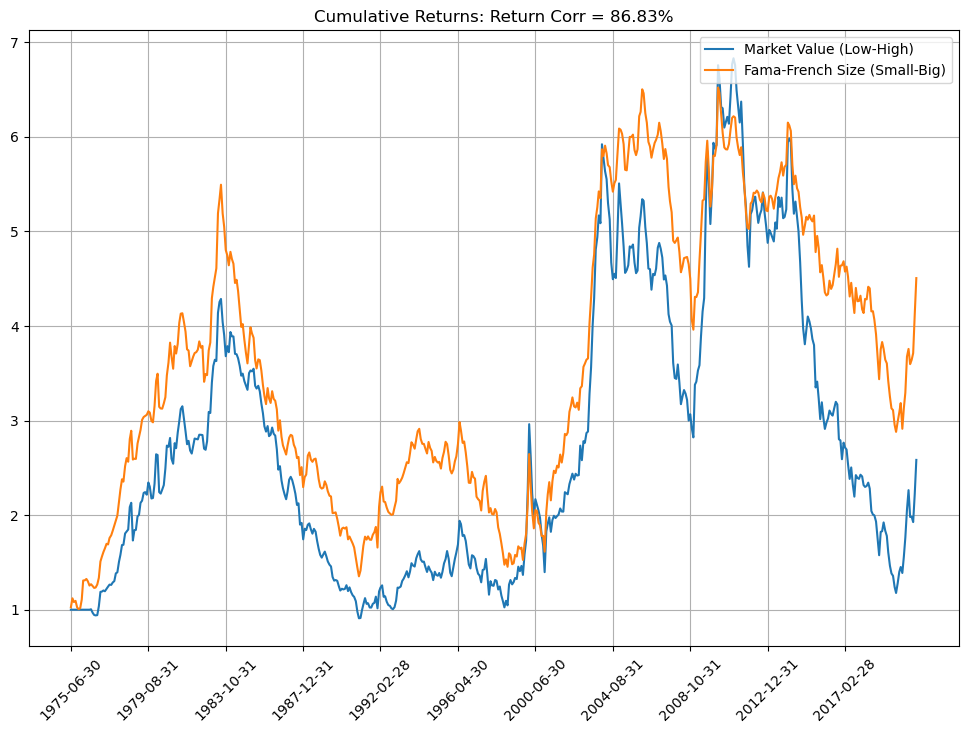

In [9]:
# Select the time to visualize
start = (1975, 6, 1)
end = (2020, 12, 31)
temp = filter_datetime_df(size_portfolio, start, end)
temp_ff = filter_datetime_df(ff_size, start, end)
# Visualization
plt.figure(figsize=(12, 8))
plt.plot(temp.index, (1+ls(temp, 0, -1)).to_numpy().cumprod(), label='Market Value (Low-High)')
plt.plot(temp.index, (1+ls(temp_ff, 0, -1)).to_numpy().cumprod(), label='Fama-French Size (Small-Big)')
corr = np.corrcoef([ls(temp, 0, -1), ls(temp_ff, 0, -1)])[0, 1]
plt.legend(loc='upper right')
plt.title(f"Cumulative Returns: Return Corr = {corr:.2%}")
plt.grid()
plt.xticks(temp.index[::50], rotation=45)
plt.show()

# Price Momentum

In [10]:
# Construct price momentum
df_mom = get_momentum(dfs['ret'])
df_mom.dropna(how="all").head()

cusip,00003210,00016510,00020910,00030710,00032Q10,00035410,00036020,00036110,00037010,00057310,...,98986X10,98987510,98987D20,98990510,98990610,98992210,98992910,G1863T10,G6516310,U7260311
date,,,,,,,,,,,,,,,,,,,,,
1976-01-30,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.098039,2.095238,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-02-27,1.714286,NaN,NaN,NaN,NaN,NaN,NaN,1.468085,1.760000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-03-31,2.083333,NaN,NaN,NaN,NaN,NaN,NaN,1.761905,1.913043,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-04-30,2.511628,NaN,NaN,NaN,NaN,NaN,NaN,1.707317,1.294118,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-05-28,2.682927,NaN,NaN,NaN,NaN,NaN,NaN,1.396552,1.571429,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


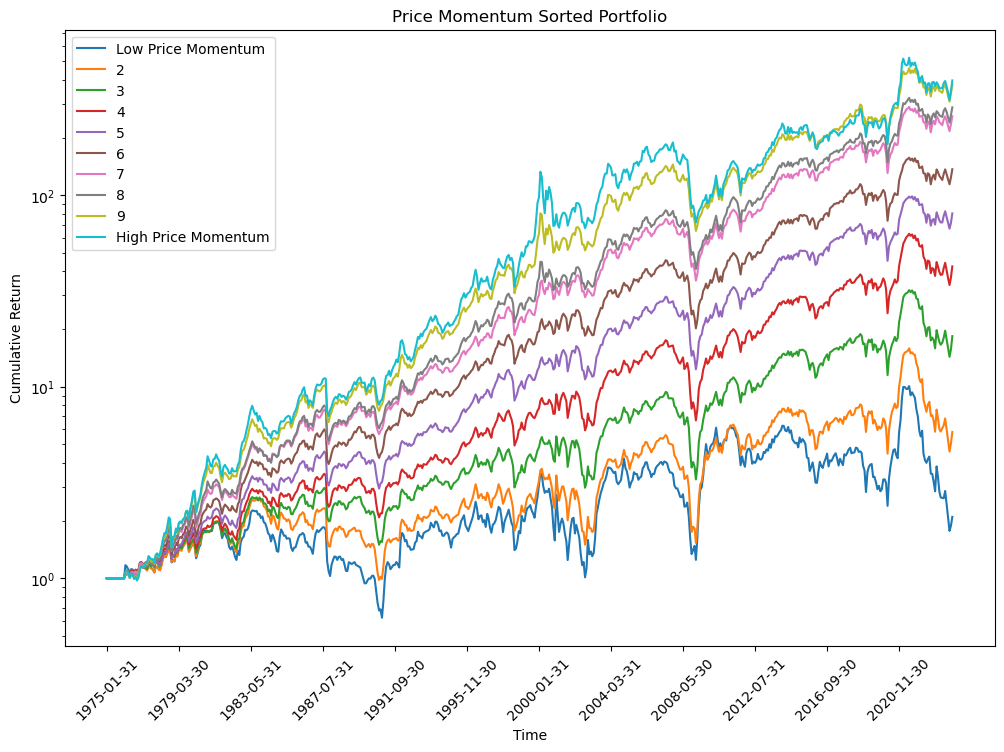

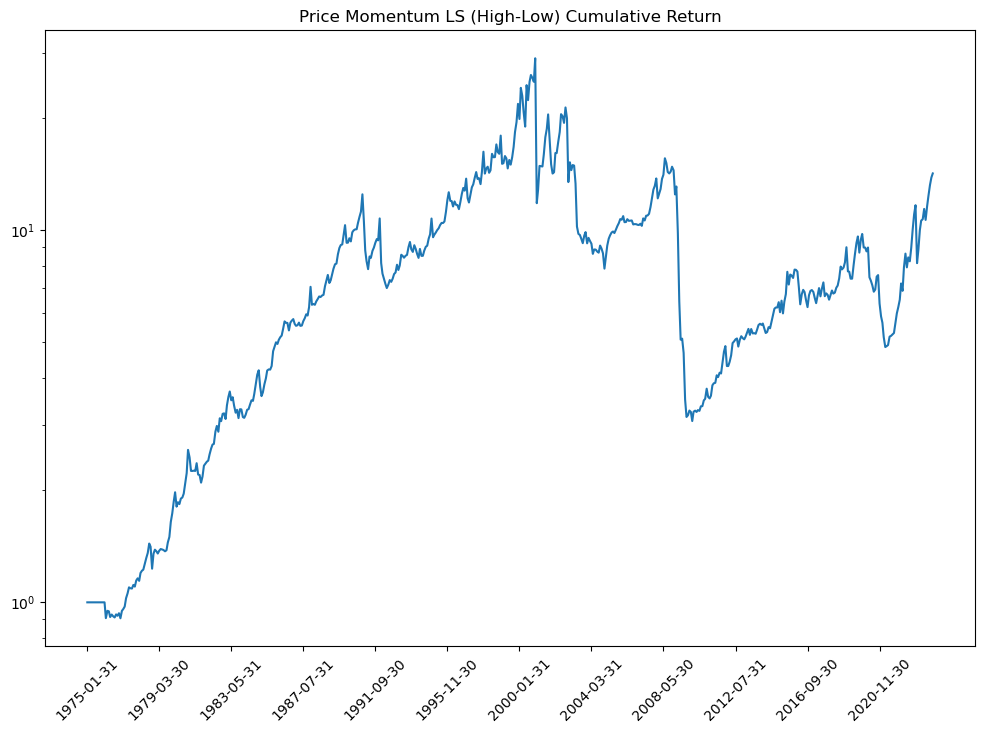

In [11]:
# Construct the quarterly-rebalanced price momentum strategy
price_momentum = forward_fill(df_mom.copy(deep=True), holding_period=3)
# Re-balance each quarter
price_momentum[~idx_Q] = np.nan
mom_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(df_mom * dfs['idx_vol_threshold'],holding_period=3)
)
# Visualization
plot_group_cum(mom_portfolio, "Price Momentum")
plot_solo_cum(ls(mom_portfolio, -1, 0), "Price Momentum LS (High-Low) Cumulative Return")

# EPS

In [12]:
# Construct earnings per share (EPS)
df_eps = get_eps_df(comp_fundq, dfs['ret'], holding_period=3)
# Re-balance every quarter
df_eps[~idx_Q] = np.nan
df_eps.dropna(how="all").head()

cusip,00003210,00016510,00020910,00030710,00032Q10,00035410,00036020,00036110,00037010,00057310,...,98986X10,98987510,98987D20,98990510,98990610,98992210,98992910,G1863T10,G6516310,U7260311
date,,,,,,,,,,,,,,,,,,,,,
1975-03-31,0.08,NaN,NaN,NaN,NaN,NaN,NaN,0.28,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-06-30,0.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-09-30,0.27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-12-31,0.27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-03-31,0.32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


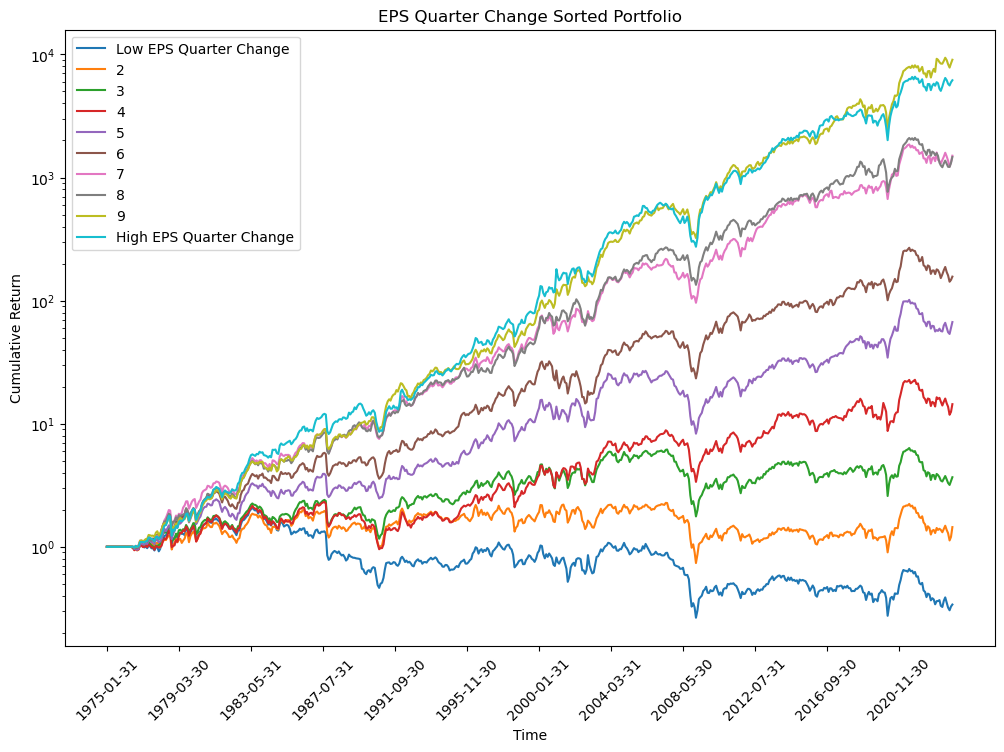

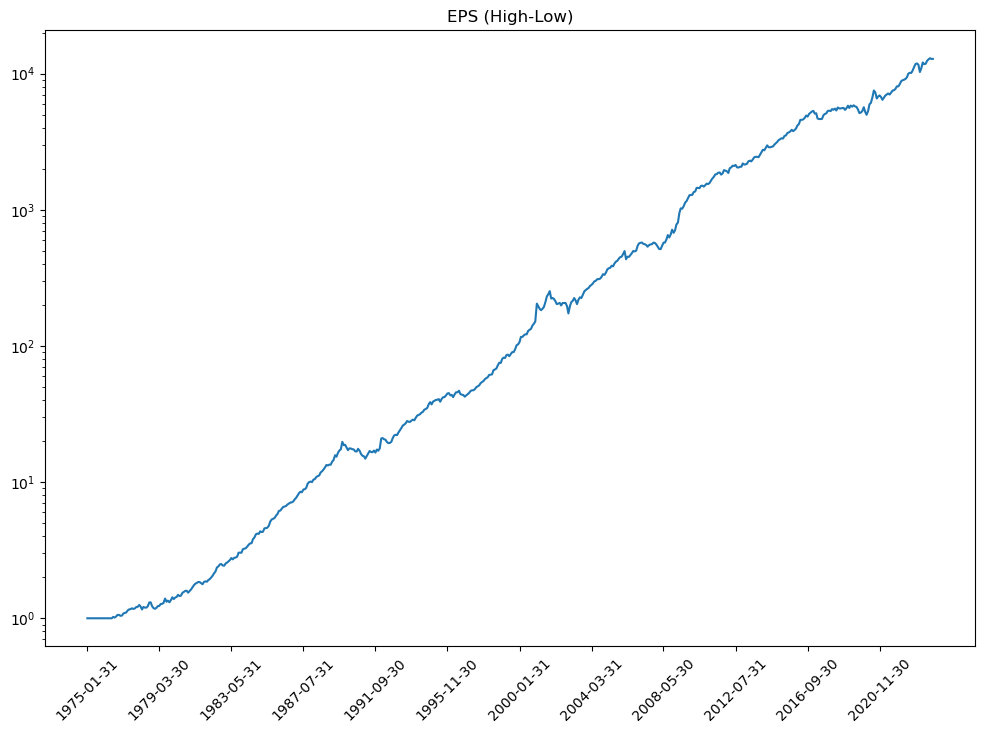

In [13]:
# Get the year over year change
df_eps_pct = df_eps.diff(3) / df_eps.rolling(window=36, min_periods=6).std()
# Compute the portfolio
eps_pct_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(df_eps_pct * dfs['idx_vol_threshold'],holding_period=3)
)
# Visualization
plot_group_cum(eps_pct_portfolio, "EPS Quarter Change")
plot_solo_cum(ls(eps_pct_portfolio, -1, 0), "EPS (High-Low)")

# PM

In [14]:
# Construct the profit margin (PM)
df_pm = get_pm_df(comp_fundq, dfs['ret'], holding_period=3)
# Re-balance every quarter
df_pm[~idx_Q] = np.nan
df_pm.dropna(how="all").head()

cusip,00003210,00016510,00020910,00030710,00032Q10,00035410,00036020,00036110,00037010,00057310,...,98986X10,98987510,98987D20,98990510,98990610,98992210,98992910,G1863T10,G6516310,U7260311
date,,,,,,,,,,,,,,,,,,,,,
1975-03-31,0.016822,NaN,NaN,NaN,NaN,NaN,NaN,0.014063,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-06-30,0.060591,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-09-30,0.046715,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975-12-31,0.049132,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1976-03-31,0.044743,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


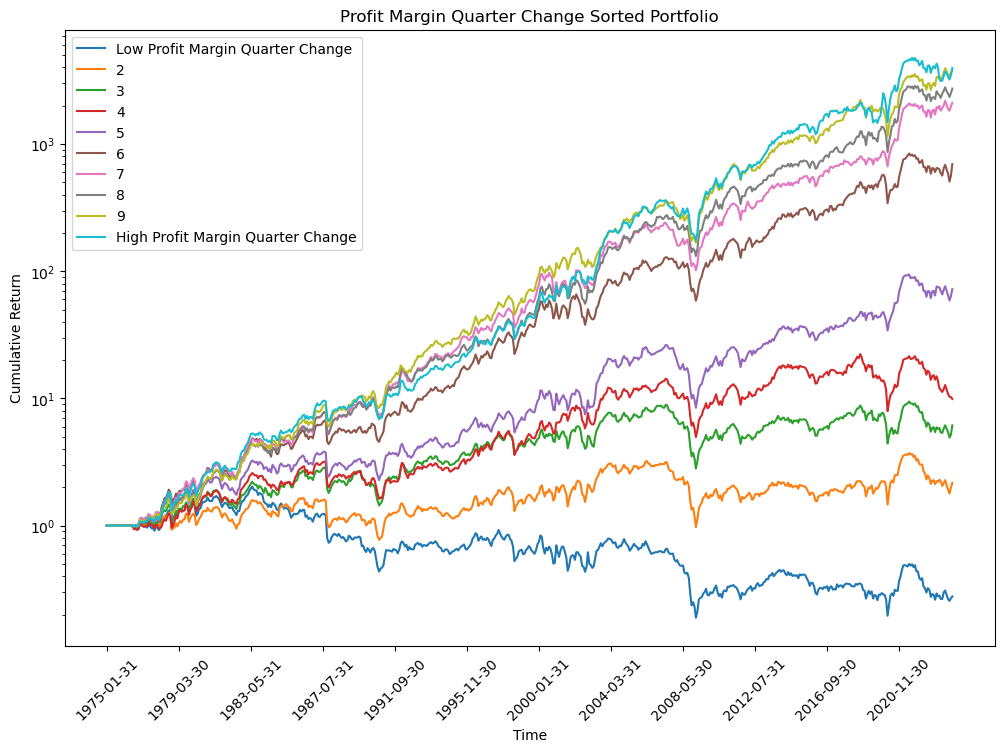

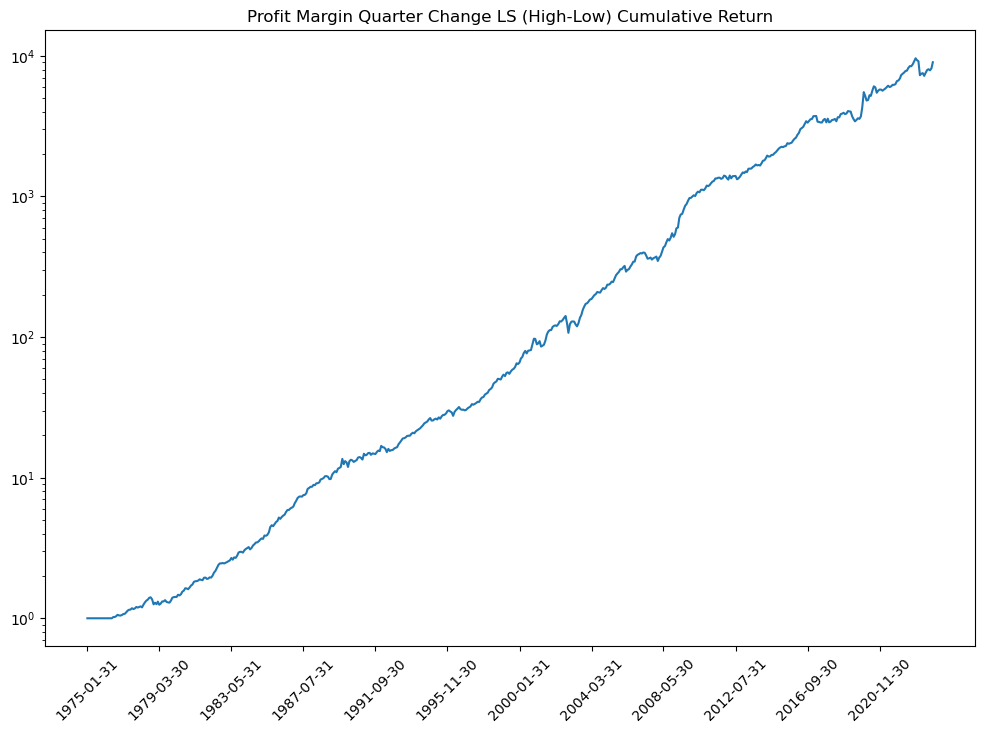

In [15]:
# Construct the profit margin quarterly change
df_pm_pct =  df_pm.diff(3) / df_pm.rolling(window=36, min_periods=6).std()
# df_pm_pct[count_non_cols(df_pm_pct) < 100] = np.nan
pm_pct_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        df_pm_pct * dfs['idx_vol_threshold'],
        holding_period=3
        )
)
plot_group_cum(pm_pct_portfolio, "Profit Margin Quarter Change")
plot_solo_cum(ls(pm_pct_portfolio, -1, 0), "Profit Margin Quarter Change LS (High-Low) Cumulative Return")